# Final model evaluation notebook

> This notebook is dedicated to evaluating final model, located in `artifacts/run_adversarial`.

## Imported modules

In [ ]:
import joblib
import json

from pathlib import Path

import pandas as pd
import numpy as np
import random

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Reproducibility

In [2]:
random.seed(42)
np.random.seed(42)

## Paths

In [3]:
RUN_ADVERSARIAL_DIR = Path("../artifacts/run_adversarial")
DATA_DIR = Path("../data")

## Model and data loading

In [4]:
model = joblib.load(RUN_ADVERSARIAL_DIR / "model.pkl")
with open(RUN_ADVERSARIAL_DIR / "best_threshold.json") as f:
    threshold = json.load(f)["threshold"]

In [5]:
df = pd.read_csv(DATA_DIR / "credit_card_fraud.csv")

# Cleansing and feature engineering 
df = df.drop_duplicates().reset_index(drop=True)
df["Amount_log"] = np.log1p(df["Amount"])
df = df.drop(columns=["Amount"])
df["Hour"] = (df["Time"] % 86400) / 3600
df = df.drop(columns=["Time"])

X = df.drop(columns=["Class"])
y = df["Class"]

X_np = X.values.astype(np.float32)
y_np = y.values

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

## Confusion Matrix

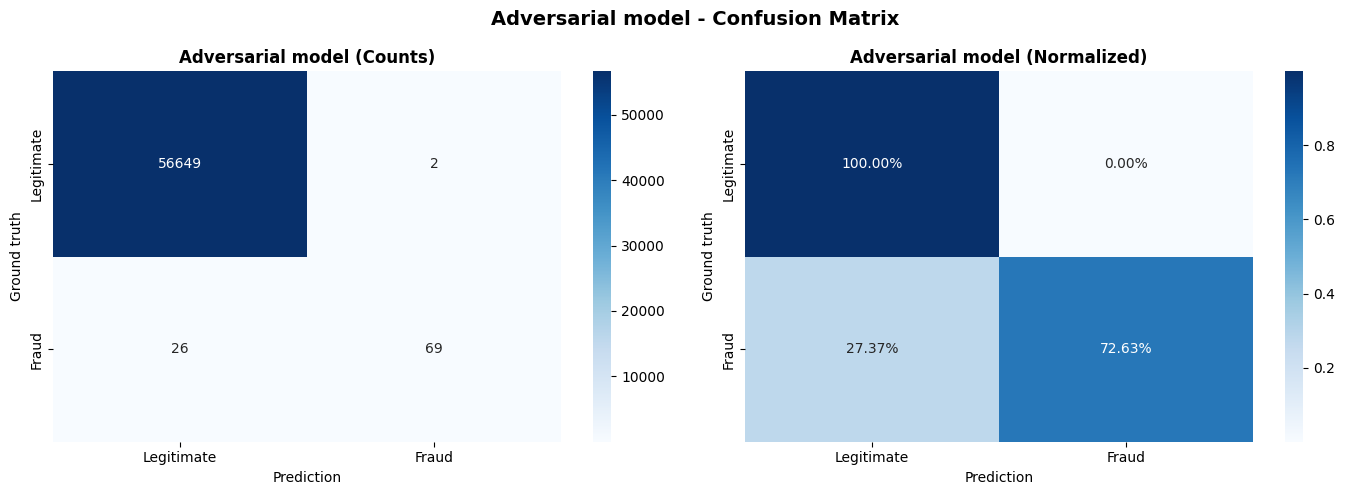

In [6]:
def plot_best_model_confusion_matrix(y_true, y_pred, model_name, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Counts
    sns.heatmap(
        cm, ax=ax1, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"]
    )
    ax1.set_ylabel("Ground truth")
    ax1.set_xlabel("Prediction")
    ax1.set_title(f"{model_name} (Counts)", fontsize=12, fontweight="bold")

    # Normalized
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, ax=ax2, annot=True, fmt=".2%", cmap="Blues",
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"]
    )
    ax2.set_ylabel("Ground truth")
    ax2.set_xlabel("Prediction")
    ax2.set_title(f"{model_name} (Normalized)", fontsize=12, fontweight="bold")

    plt.suptitle(f"{model_name} - Confusion Matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


y_proba_best = model.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba_best >= threshold).astype(int)

plot_best_model_confusion_matrix(
    y_test,
    y_pred_best,
    model_name="Adversarial model",
    save_path=RUN_ADVERSARIAL_DIR / "confusion_matrix.png"
)

Prediction quality, luckily, didn't lower much.